<a href="https://colab.research.google.com/github/millerfabiancanon-a11y/Business_Analytics/blob/main/Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Proyecto de Análisis Descriptivo – Business Analytics

## Proyectos de Financiamiento del Banco Mundial

**Estudiante:** Miller Fabian Cañon Cañón

**Curso:** Business Analytics

**Base de datos de partida:** `projects_clean.parquet` (resultado del proceso ETL desarrollado previamente)

**Link Repositorio Github:**

---
## 📌 Introducción

El **análisis descriptivo** responde a la pregunta *¿qué pasó?*: resume y visualiza los datos para entender su comportamiento antes de intentar explicarlos o predecirlos. Es el paso natural que sigue a un proceso ETL, porque solo con datos limpios y bien estructurados las estadísticas y las gráficas son confiables.

Este notebook parte del dataset que dejó listo el ETL (proyectos de financiamiento del Banco Mundial, 18,049 filas y 33 columnas) y desarrolla cuatro etapas:

1. **Carga y exploración de datos** – leer el archivo limpio y revisar su estructura.
2. **Limpieza y organización de la información** – verificar la calidad de los datos, corregir lo que haga falta y crear las columnas necesarias para el análisis.
3. **Cálculo de estadísticas descriptivas** – medidas de tendencia central, dispersión y comparaciones por grupo.
4. **Generación de visualizaciones** – gráficas que muestran los hallazgos principales.

### Preguntas que guían el análisis

- ¿Cómo se distribuyen los proyectos y el dinero entre las regiones del mundo?
- ¿Cuánto financiamiento recibe un proyecto "típico", y cómo se comparan el promedio y la mediana?
- ¿Cómo ha evolucionado el número de proyectos aprobados a lo largo del tiempo?
- ¿Cuánto dura un proyecto y cambia según su estado?
- ¿Qué países concentran el mayor financiamiento?

### Alcance de los datos

El dataset cubre proyectos aprobados entre **1947 y junio de 2018**. Los montos están en dólares (USD).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Formato de números en las tablas: separador de miles y 1 decimal
pd.options.display.float_format = "{:,.1f}".format

# Estilo de las gráficas: un solo color, sin bordes sobrantes
COLOR = "#2a78d6"
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
})

---
## 📂 1. Carga y exploración de datos

En esta sección se conecta el notebook con Google Drive, se lee el archivo limpio generado por el ETL y se hace una primera revisión: dimensiones, primeras filas, tipos de dato y valores nulos.

Se usa el formato **Parquet** porque conserva los tipos de dato: las fechas llegan como fechas y los montos como números, sin necesidad de volver a convertirlos.

In [2]:
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/projects_clean.parquet"
df = pd.read_parquet(ruta)

print("Dimensiones (filas, columnas):", df.shape)
df.head()

Mounted at /content/drive
Dimensiones (filas, columnas): (18049, 33)


,id,regionname,countryname,prodline,lendinginstr,lendinginstrtype,envassesmentcategorycode,supplementprojectflg,productlinetype,status,...,sector2,sector3,sector,mjsector,theme1,theme2,theme3,goal,financier,project_duration_days
0,P162228,Other,World,RE,Investment Project Financing,IN,C,N,L,Active,...,Not specified,Not specified,Not specified,Not specified,!$!0,Not specified,Not specified,Not specified,Not specified,NaN
1,P163962,Africa,Democratic Republic of the Congo,PE,Investment Project Financing,IN,B,N,L,Active,...,Not specified,Not specified,Not specified,Not specified,!$!0,Not specified,Not specified,Not specified,Not specified,"2,012.0"
2,P167672,South Asia,People's Republic of Bangladesh,PE,Investment Project Financing,IN,Not specified,Y,L,Active,...,Not specified,Not specified,Not specified,Not specified,!$!0,Not specified,Not specified,Not specified,Not specified,NaN
3,P158768,South Asia,Islamic Republic of Afghanistan,PE,Investment Project Financing,IN,A,N,L,Active,...,Not specified,Not specified,Not specified,Not specified,!$!0,Not specified,Not specified,Not specified,Not specified,"1,827.0"
4,P161364,Africa,Federal Republic of Nigeria,PE,Investment Project Financing,IN,B,N,L,Active,...,Other Industry; Trade and Services!$!25!$!YZ,Other Agriculture; Fishing and Forestry!$!2!$!AZ,Social Protection;Social Protection;Other Indu...,Social Protection;Social Protection;Industry; ...,!$!0,Not specified,Not specified,Not specified,Not specified,"1,799.0"


Se espera ver **18,049 filas y 33 columnas**, que es el resultado final del ETL. Si salen otras dimensiones, el archivo guardado corresponde a una versión anterior del proceso.

Ahora se revisa el nombre, el tipo de dato y la cantidad de valores no nulos de cada columna:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18049 entries, 0 to 18048
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   id                        18049 non-null  object             
 1   regionname                18049 non-null  object             
 2   countryname               18049 non-null  object             
 3   prodline                  18049 non-null  object             
 4   lendinginstr              18049 non-null  object             
 5   lendinginstrtype          18049 non-null  object             
 6   envassesmentcategorycode  18049 non-null  object             
 7   supplementprojectflg      18049 non-null  object             
 8   productlinetype           18049 non-null  object             
 9   status                    18049 non-null  object             
 10  project_name              18049 non-null  object             
 11  boardapprovalda

### Lectura de la estructura

- Las **columnas de monto** (`totalamt`, `grantamt`, `ibrdcommamt`, `idacommamt`, `lendprojectcost`) son numéricas (`float64`) y las **columnas de fecha** (`boardapprovaldate`, `closingdate`) son de tipo fecha, tal como lo dejó el ETL.
- El resto de columnas son de texto (`object`): identificadores, nombres, región, país, estado, sectores y temas.

A continuación se revisan los valores nulos que quedan y si hay proyectos repetidos:

In [4]:
nulos = df.isnull().sum()
print("Columnas que aún tienen valores nulos:")
print(nulos[nulos > 0])
print()
print("IDs de proyecto repetidos:", df["id"].duplicated().sum())

Columnas que aún tienen valores nulos:
boardapprovaldate        1466
closingdate              3260
project_duration_days    3297
dtype: int64

IDs de proyecto repetidos: 0


### Nulos que se conservan a propósito

Solo quedan nulos en tres columnas, y en los tres casos **son información real**, no errores:

- `boardapprovaldate` (**1,466 nulos**): proyectos sin fecha de aprobación registrada. Más adelante se verá que corresponden, en su mayoría, a proyectos que nunca fueron aprobados.
- `closingdate` (**3,260 nulos**): proyectos que aún no tienen fecha de cierre.
- `project_duration_days` (**3,297 nulos**): la duración no se puede calcular cuando falta alguna de las dos fechas, o en los 14 casos en que el ETL detectó una duración negativa (fecha de cierre anterior a la de aprobación) y la dejó vacía.

Tampoco hay proyectos repetidos: cada `id` aparece una sola vez.

---
## 🧹 2. Limpieza y organización de la información

La limpieza principal ya se hizo en el ETL (columnas vacías, tipos de dato, nulos, filtros de negocio). En esta etapa se hace lo que el análisis específicamente necesita:

1. Crear el **año de aprobación** como columna propia.
2. Revisar las **categorías** que se van a usar para agrupar.
3. Detectar y tratar **valores atípicos o sospechosos** en los montos.
4. Construir una **medida de financiamiento total** que no deje por fuera las donaciones.
5. Unificar los nombres de país que tienen **espacios duplicados**.

### 2.1 Año de aprobación

Para estudiar la evolución en el tiempo se necesita el año como columna independiente. Se extrae de la fecha de aprobación; los proyectos sin fecha quedan sin año.

In [5]:
# Int64 (con I mayúscula) permite números enteros que también admiten nulos
df["approval_year"] = df["boardapprovaldate"].dt.year.astype("Int64")

print("Primer año:", df["approval_year"].min(), "| Último año:", df["approval_year"].max())
print("Proyectos sin año de aprobación:", df["approval_year"].isnull().sum())

Primer año: 1947 | Último año: 2018
Proyectos sin año de aprobación: 1466


El rango es **1947–2018** y los nulos coinciden con los de la fecha original (1,466), así que el rango es coherente con un dataset histórico y no hay años anómalos.

### 2.2 Revisión de las categorías de agrupación

Antes de agrupar por estado y por región se revisa qué valores existen y cuántos proyectos tiene cada uno.

In [6]:
print(df["status"].value_counts())
print()
print(df["regionname"].value_counts())

status
Closed           13856
Active            2725
Dropped            934
Pipeline           530
Not specified        4
Name: count, dtype: int64

regionname
Africa                          5625
Latin America and Caribbean     3278
East Asia and Pacific           2889
Europe and Central Asia         2456
South Asia                      2211
Middle East and North Africa    1483
Other                            107
Name: count, dtype: int64


- **Estado:** hay cuatro estados reales (`Closed`, `Active`, `Dropped`, `Pipeline`) y **4 proyectos** con `Not specified`, que es la etiqueta que puso el ETL donde el dato original estaba vacío. Son pocos y no distorsionan el análisis.
- **Región:** seis regiones geográficas y una categoría `Other` (107 proyectos), que parece agrupar proyectos de alcance global. Se mantiene, pero sin sacar conclusiones fuertes de ella por su tamaño.

### 2.3 Valores atípicos en `lendprojectcost`

Al revisar los montos máximos, la columna `lendprojectcost` (costo del proyecto) muestra valores muy superiores a los del resto de columnas de dinero. Se revisan los casos que superan los **10 mil millones de USD**, comparándolos con `totalamt` del mismo proyecto:

In [7]:
extremos = df[df["lendprojectcost"] > 10_000_000_000].copy()
extremos["veces_vs_totalamt"] = extremos["lendprojectcost"] / extremos["totalamt"]

print("Proyectos con lendprojectcost > 10 mil millones:", len(extremos))
extremos[["id", "project_name", "status", "totalamt", "lendprojectcost", "veces_vs_totalamt"]].sort_values("veces_vs_totalamt")

Proyectos con lendprojectcost > 10 mil millones: 13


,id,project_name,status,totalamt,lendprojectcost,veces_vs_totalamt
4271,P116410,Eskom Investment Support Project,Active,"3,750,000,000.0","10,750,000,000.0",2.9
1266,P153251,IN Swachh Bharat Mission Support Operation,Active,"1,500,000,000.0","22,000,000,000.0",14.7
4324,P116226,Support to the Social Protection System in Health,Closed,"1,250,000,000.0","26,861,000,000.0",21.5
48,P162619,Quality Learning for All Program,Active,"700,000,000.0","16,000,000,000.0",22.9
3117,P118445,India: Secondary Education Project,Closed,"500,000,000.0","12,896,000,000.0",25.8
2045,P144447,India: Elementary Education III,Closed,"1,006,200,000.0","29,833,300,000.0",29.6
377,P161373,Enhancing Shared Prosperity through Equitable ...,Active,"700,000,000.0","21,023,700,000.0",30.0
4855,P107559,Guiyang Guangzhou Railway,Closed,"300,000,000.0","12,527,000,000.0",41.8
34,P164686,Investing in Nutrition and Early Years,Active,"400,000,000.0","21,243,000,000.0",53.1
16745,P165178,Capital Market; Infrastructure Bond Liquidity ...,Pipeline,"450,000,000.0","26,001,130,000.0",57.8


### Decisión sobre estos valores

La tabla muestra dos situaciones distintas:

- **Un registro de prueba:** el proyecto `P159145` se llama *"testing ipf project in OPS 3 january release 1243"* y tiene un `totalamt` de solo 140,000 USD frente a un `lendprojectcost` de 89,100 millones. No es un proyecto real, por lo que **se elimina**. Se filtra por `id` y no por el texto "testing" para no borrar proyectos legítimos que contengan esa palabra.
- **Doce proyectos reales con un costo desproporcionado:** su `lendprojectcost` es entre **3 y 620 veces** su `totalamt`; en 11 de los 12 casos, más de 14 veces. Es cierto que el costo total de un proyecto puede superar el monto que aporta el Banco (por ejemplo, por cofinanciamiento), pero múltiplos de ese tamaño son poco plausibles, y no hay un diccionario de datos para confirmar las unidades. Como no se pueden corregir con certeza, **no se eliminan los proyectos** (conservan todos sus demás datos), pero **la columna `lendprojectcost` se excluye del análisis** y queda documentada como limitación.

Además, en el ETL los nulos de `lendprojectcost` (0.7%) se rellenaron con la mediana, otra razón para no apoyarse en esa columna.

In [8]:
df = df[df["id"] != "P159145"].copy()

print("Dimensiones después de quitar el registro de prueba:", df.shape)

Dimensiones después de quitar el registro de prueba: (18048, 34)


### 2.4 Medida de financiamiento total

Hay proyectos con `totalamt = 0` que sin embargo tienen dinero asignado por **donación** (`grantamt`). Si se analizara solo `totalamt`, esos proyectos aparecerían como si no tuvieran financiamiento. Por eso se crea `total_financing`, que suma el préstamo y la donación de cada proyecto.

Antes de sumar, se verifica que ambas columnas no se solapen (que ningún proyecto tenga préstamo y donación a la vez), para no contar dinero dos veces:

In [9]:
ambos = ((df["totalamt"] > 0) & (df["grantamt"] > 0)).sum()
print("Proyectos con préstamo Y donación a la vez:", ambos)

df["total_financing"] = df["totalamt"] + df["grantamt"]

Proyectos con préstamo Y donación a la vez: 0


Si el resultado es **0**, cada proyecto se financia por una vía o por la otra, y la suma de ambas columnas representa el financiamiento real sin duplicar montos.

### 2.5 Unificación de nombres de país

Algunos nombres de país traen **espacios dobles** en medio del texto (por ejemplo, `"Islamic  Republic of Afghanistan"`). Para el análisis, eso podría separar un mismo país en dos grupos distintos, así que se normalizan los espacios.

In [10]:
df["countryname"] = df["countryname"].str.replace(r"\s+", " ", regex=True).str.strip()

print("Nombres de país distintos (incluye 'World'):", df["countryname"].nunique())

Nombres de país distintos (incluye 'World'): 206


### 2.6 Resultado de la limpieza y organización

Con esto el dataset queda listo para el análisis.

In [11]:
print("Dimensiones listas para el análisis:", df.shape)
print("Columnas agregadas en esta etapa: approval_year, total_financing")

Dimensiones listas para el análisis: (18048, 35)
Columnas agregadas en esta etapa: approval_year, total_financing


Quedan **18,048 filas y 35 columnas**: una fila menos (el registro de prueba) y dos columnas más (`approval_year` y `total_financing`).

---
## 📐 3. Cálculo de estadísticas descriptivas

En esta sección se resumen numéricamente los datos: medidas generales de las columnas de dinero y de duración, y luego comparaciones por región, por estado y por país.

### 3.1 Resumen general de las variables numéricas

`describe()` calcula de una vez el conteo, el promedio (`mean`), la desviación estándar (`std`), el mínimo, los percentiles (25%, 50% y 75%) y el máximo. El **50% es la mediana**: el valor central, que deja la mitad de los datos por debajo y la otra mitad por encima.

In [12]:
columnas_numericas = ["totalamt", "grantamt", "total_financing", "ibrdcommamt", "idacommamt", "project_duration_days"]

df[columnas_numericas].describe()

,totalamt,grantamt,total_financing,ibrdcommamt,idacommamt,project_duration_days
count,"18,048.0","18,048.0","18,048.0","18,048.0","18,048.0","14,752.0"
mean,"65,668,919.5","1,909,844.9","67,578,764.4","42,870,745.2","22,798,173.8","2,089.5"
std,"127,922,975.0","42,489,997.2","133,861,266.2","120,441,262.7","58,491,676.5",950.9
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,"5,000,000.0",0.0,"7,500,000.0",0.0,0.0,"1,487.5"
50%,"24,000,000.0",0.0,"25,000,000.0",0.0,0.0,"2,142.0"
75%,"73,025,000.0",0.0,"75,000,000.0","30,500,000.0","20,000,000.0","2,741.0"
max,"3,750,000,000.0","5,330,000,000.0","5,330,000,000.0","3,750,000,000.0","1,200,000,000.0","8,439.0"


### Interpretación

- **Los montos están muy sesgados a la derecha.** En `total_financing`, la mediana es de **25 millones** pero el promedio es de **67.6 millones**: unos pocos proyectos muy grandes jalan el promedio hacia arriba. Para describir un proyecto "típico" es más representativa la **mediana**.
- **Las donaciones son poco frecuentes.** En `grantamt` el percentil 75 es 0, es decir, más de tres cuartas partes de los proyectos no recibe donación; el promedio de 1.9 millones lo generan pocos casos extremos.
- **Duración:** los 14,752 proyectos con duración calculada tienen una mediana de **2,142 días (unos 5.9 años)**, un promedio similar (2,089 días) y un máximo de 8,439 días (más de 23 años).

### 3.2 Promedio frente a mediana y proyectos sin préstamo

Se cuantifica cuánto distorsiona el promedio y cuántos proyectos no tienen préstamo:

In [13]:
media = df["total_financing"].mean()
mediana = df["total_financing"].median()

print(f"Promedio de total_financing: {media:,.0f}")
print(f"Mediana de total_financing:  {mediana:,.0f}")
print(f"El promedio es {media / mediana:.1f} veces la mediana")
print()

sin_prestamo = (df["totalamt"] == 0).sum()
con_donacion = ((df["totalamt"] == 0) & (df["grantamt"] > 0)).sum()
sin_nada = (df["total_financing"] == 0).sum()

print(f"Proyectos sin préstamo (totalamt = 0): {sin_prestamo:,} ({sin_prestamo / len(df):.1%} del total)")
print(f"   de ellos, financiados por donación: {con_donacion:,}")
print(f"   de ellos, sin ningún financiamiento registrado: {sin_nada:,}")

Promedio de total_financing: 67,578,764
Mediana de total_financing:  25,000,000
El promedio es 2.7 veces la mediana

Proyectos sin préstamo (totalamt = 0): 3,404 (18.9% del total)
   de ellos, financiados por donación: 3,305
   de ellos, sin ningún financiamiento registrado: 99


### Interpretación

- El promedio es unas **2.7 veces** la mediana, confirmando el sesgo.
- **3,404 proyectos (18.9%)** no tienen préstamo; de ellos, **3,305 se financian con donaciones**. Sin la columna `total_financing`, esos proyectos se habrían leído como "sin dinero" y se habría subestimado el financiamiento real.
- Solo **99 proyectos** no tienen financiamiento registrado por ninguna vía (40 `Active`, 32 `Dropped` y 27 `Pipeline`). Ya no hay ninguno `Closed`, porque el ETL los filtró.

### 3.3 Financiamiento por región

Se agrupan los proyectos por región y se calcula, para cada una, cuántos proyectos hay, la mediana del financiamiento por proyecto y el financiamiento total.

In [14]:
resumen_region = (
    df.groupby("regionname")["total_financing"]
    .agg(proyectos="count", mediana="median", total="sum")
    .sort_values("total", ascending=False)
)
resumen_region["pct_del_total"] = resumen_region["total"] / resumen_region["total"].sum() * 100

resumen_region

,proyectos,mediana,total,pct_del_total
regionname,,,,
Latin America and Caribbean,3278,"27,000,000.0","255,313,100,000.0",20.9
Africa,5625,"18,000,000.0","234,591,190,000.0",19.2
South Asia,2211,"50,000,000.0","231,565,750,000.0",19.0
East Asia and Pacific,2889,"31,000,000.0","222,794,040,000.0",18.3
Europe and Central Asia,2456,"25,000,000.0","186,500,140,000.0",15.3
Middle East and North Africa,1483,"25,000,000.0","88,644,080,000.0",7.3
Other,106,"500,000.0","253,240,000.0",0.0


### Interpretación

- **Más proyectos no significa más dinero.** África tiene el mayor número de proyectos (**5,625**, el 31% del total) pero su mediana es de solo **18 millones**; Latinoamérica y el Caribe, con menos proyectos (3,278), lidera en financiamiento total (**255,313 millones**, 20.9%).
- **Asia del Sur es el caso opuesto a África:** pocos proyectos (2,211) pero los más grandes, con una mediana de **50 millones**, casi el triple que la de África.
- Las cinco regiones principales concentran montos totales parecidos (entre 187 y 255 mil millones); **Medio Oriente y Norte de África** queda más abajo (88.6 mil millones) y `Other` es marginal (0.25 mil millones, con una mediana de 0.5 millones).

### 3.4 Financiamiento por estado del proyecto

In [15]:
resumen_estado = (
    df.groupby("status")["total_financing"]
    .agg(proyectos="count", mediana="median", total="sum")
    .sort_values("total", ascending=False)
)

resumen_estado

,proyectos,mediana,total
status,,,
Closed,13856,"22,600,000.0","844,202,260,000.0"
Active,2725,"40,000,000.0","254,130,550,000.0"
Dropped,934,"37,600,000.0","75,026,510,000.0"
Pipeline,529,"40,500,000.0","46,175,160,000.0"
Not specified,4,"6,905,000.0","127,060,000.0"


### Interpretación

- Los proyectos **`Closed`** concentran la mayor parte del dinero (**844 mil millones**) simplemente porque son la gran mayoría (13,856 de 18,048).
- Los proyectos **`Active`** (mediana de 40 millones) y **`Pipeline`** (40.5 millones) son **más grandes** que los `Closed` (22.6 millones). Una explicación posible es que los proyectos recientes son más grandes, pero es solo una hipótesis.
- Los proyectos **`Dropped`** (cancelados) suman 75 mil millones en 934 proyectos, es decir, financiamiento que se comprometió y no se ejecutó.

### 3.5 Duración de los proyectos por estado

Se cuenta, para cada estado, cuántos proyectos tienen fecha de aprobación, cuántos tienen duración calculada y cuál es la mediana de duración.

In [17]:
resumen_duracion = df.groupby("status").agg(
    proyectos=("id", "count"),
    con_aprobacion=("boardapprovaldate", "count"),
    con_duracion=("project_duration_days", "count"),
    mediana_dias=("project_duration_days", "median"),
)
resumen_duracion["mediana_años"] = resumen_duracion["mediana_dias"] / 365.25

resumen_duracion

,proyectos,con_aprobacion,con_duracion,mediana_dias,mediana_años
status,,,,,
Active,2725,2725,2140,"2,062.5",5.6
Closed,13856,13855,12612,"2,173.0",5.9
Dropped,934,0,0,NaN,NaN
Not specified,4,3,0,NaN,NaN
Pipeline,529,0,0,NaN,NaN


### Interpretación

- **Los proyectos `Dropped` y `Pipeline` no tienen duración porque nunca tuvieron fecha de aprobación** (0 de 934 y 0 de 529). Tiene sentido: son proyectos cancelados o aún en preparación, que no llegaron a ser aprobados formalmente. La duración solo se puede calcular para `Active` y `Closed`.
- La mediana es muy parecida: **2,062 días (5.6 años)** en `Active` y **2,173 días (5.9 años)** en `Closed`. Un proyecto típico dura cerca de seis años.
- **Cuidado al comparar:** en `Active` la duración es **planeada** (fecha de cierre prevista menos fecha de aprobación), mientras que en `Closed` es la duración real. Además, 585 proyectos `Active` aún no tienen fecha de cierre y quedan fuera de este cálculo.

### 3.6 Países con mayor financiamiento

Se suma el financiamiento por país y se muestran los diez primeros. Se excluye la fila `World`, que no es un país sino proyectos de alcance multinacional.

In [18]:
paises = (
    df[df["countryname"] != "World"]
    .groupby("countryname")["total_financing"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

participacion_top10 = paises.sum() / df["total_financing"].sum() * 100
print(f"El top 10 concentra el {participacion_top10:.1f}% del financiamiento total")
print()

(paises / 1e9).round(1)

El top 10 concentra el 46.4% del financiamiento total



,total_financing
countryname,
Republic of India,132.1
People's Republic of China,67.9
Federative Republic of Brazil,64.9
Republic of Indonesia,60.4
United Mexican States,57.6
Republic of Turkey,43.2
Islamic Republic of Pakistan,40.3
Argentine Republic,37.2
People's Republic of Bangladesh,34.7


### Interpretación

- **India lidera con una diferencia grande:** **132.1 mil millones** de USD, casi el doble que China (67.9) y cerca del **10.8%** del financiamiento total del dataset.
- Los **diez países del ranking concentran el 46.4%** del dinero, aunque el dataset incluye más de 200 países y territorios: el financiamiento está muy concentrado.
- Esto ayuda a explicar los resultados regionales: Brasil, México y Argentina impulsan a Latinoamérica; India, Pakistán y Bangladesh a Asia del Sur. **Nigeria** es el único país africano del ranking y está en el último lugar, coherente con que África tenga muchos proyectos pequeños repartidos entre muchos países.

---
## 📈 4. Generación de visualizaciones

Cada gráfica responde una de las preguntas planteadas al inicio. Se mantiene un estilo simple: un solo color, títulos claros, y valores escritos sobre las barras para no depender de leer los ejes.

### 4.1 Proyectos y dinero por región

Se comparan **dos medidas de las mismas regiones lado a lado**: cuántos proyectos tiene cada una (izquierda) y cuánto financiamiento suma (derecha). Ambos paneles usan el mismo orden de regiones para que el contraste se vea directamente.

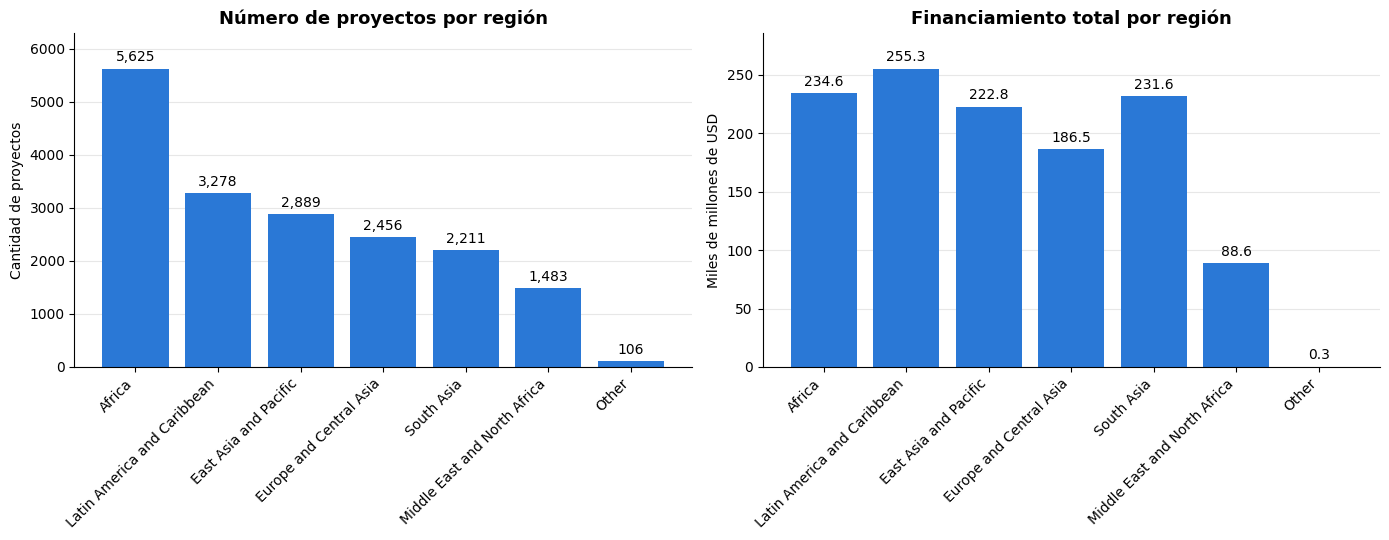

In [19]:
proyectos = df["regionname"].value_counts()          # proyectos por región (ya ordenado de mayor a menor)
orden = proyectos.index                              # ese orden se reutiliza en ambos paneles
dinero = df.groupby("regionname")["total_financing"].sum().reindex(orden) / 1e9   # en miles de millones

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel izquierdo: cantidad de proyectos
barras1 = ax1.bar(orden, proyectos.values, color=COLOR)
ax1.bar_label(barras1, fmt="{:,.0f}", padding=3)
ax1.set_title("Número de proyectos por región")
ax1.set_ylabel("Cantidad de proyectos")

# Panel derecho: financiamiento total
barras2 = ax2.bar(orden, dinero.values, color=COLOR)
ax2.bar_label(barras2, fmt="{:,.1f}", padding=3)
ax2.set_title("Financiamiento total por región")
ax2.set_ylabel("Miles de millones de USD")

for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)                           # la cuadrícula queda detrás de las barras
    ax.margins(y=0.12)                               # deja espacio arriba para las etiquetas
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Lectura de la gráfica

África encabeza la cantidad de proyectos (5,625) y `Other` es la región con menos (106), pero el panel derecho cambia el orden: **Latinoamérica y el Caribe es la que más dinero suma** (255 mil millones), seguida de África (235) y Asia del Sur (232), esta última con muchos menos proyectos que África. Es decir, **África tiene muchos proyectos pequeños, mientras que Asia del Sur tiene pocos pero grandes**.

### 4.2 Distribución del financiamiento por proyecto

Un **histograma** agrupa los proyectos por rangos de monto y muestra cuántos caen en cada rango. Como los montos van desde miles hasta miles de millones de dólares, se usa una **escala logarítmica** en el eje horizontal: cada marca es diez veces la anterior. Sin ella, casi todos los proyectos se verían pegados a la izquierda. Se excluyen los 99 proyectos con financiamiento cero, porque el logaritmo no admite ceros.

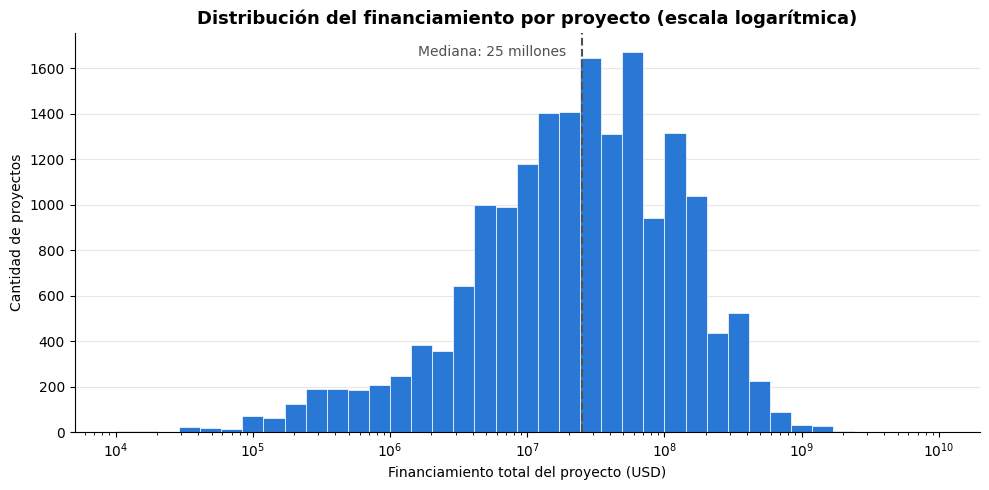

In [20]:
financiamiento = df.loc[df["total_financing"] > 0, "total_financing"]
mediana_pos = financiamiento.median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(financiamiento, bins=np.logspace(4, 10, 40), color=COLOR, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")

# Línea vertical punteada con la mediana; el texto va a la izquierda de la línea (zona sin barras altas)
ax.axvline(mediana_pos, color="#52514e", linestyle="--", linewidth=1.5)
ax.text(mediana_pos / 1.3, ax.get_ylim()[1] * 0.97, f"Mediana: {mediana_pos / 1e6:,.0f} millones",
        ha="right", va="top", color="#52514e")

ax.set_title("Distribución del financiamiento por proyecto (escala logarítmica)")
ax.set_xlabel("Financiamiento total del proyecto (USD)")
ax.set_ylabel("Cantidad de proyectos")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Lectura de la gráfica

- En escala logarítmica la distribución tiene forma de **campana**: la mayoría de los proyectos se concentra entre **10 y 100 millones de USD**, con el pico cerca de la mediana (25 millones).
- La **cola izquierda es más larga**: hay proyectos pequeños desde decenas de miles de dólares. A la derecha, muy pocos superan los mil millones.
- Los "dientes" irregulares (por ejemplo, la caída cerca de 100 millones) probablemente se deben a que los montos suelen ser cifras redondas (50 M, 100 M) y a cómo se reparten en los rangos, no a un fenómeno real.
- Esta forma explica por qué el promedio (67.6 millones) supera tanto a la mediana.

### 4.3 Proyectos aprobados por año

Una **gráfica de líneas** es la forma natural de ver cómo cambia algo en el tiempo. Se cuentan los proyectos aprobados cada año y se marcan el año pico y el último año, que está incompleto.

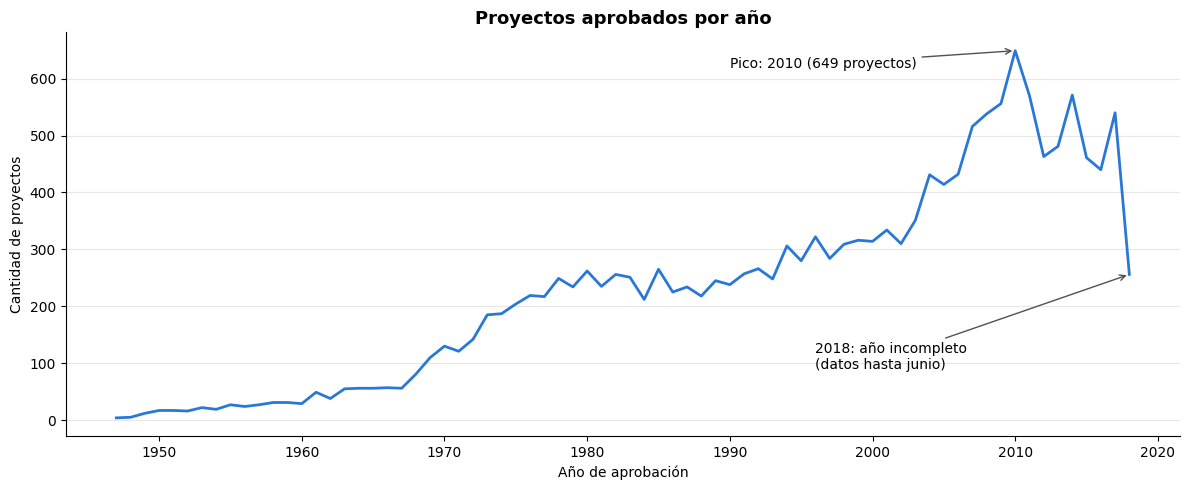

In [24]:
proyectos_por_año = df["approval_year"].value_counts().sort_index()
anios = proyectos_por_año.index.astype(int)
cantidades = proyectos_por_año.values.astype(int)

año_pico = int(proyectos_por_año.idxmax())
max_proyectos = int(proyectos_por_año.max())
ultimo_año = int(anios.max())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(anios, cantidades, color=COLOR, linewidth=2)

# Anotaciones: el año con más proyectos y el último año (incompleto)
ax.annotate(f"Pico: {año_pico} ({max_proyectos} proyectos)", xy=(año_pico, max_proyectos),
            xytext=(1990, max_proyectos - 30), arrowprops=dict(arrowstyle="->", color="#52514e"))
ax.annotate(f"{ultimo_año}: año incompleto\n(datos hasta junio)", xy=(ultimo_año, cantidades[-1]),
            xytext=(1996, 90), arrowprops=dict(arrowstyle="->", color="#52514e"))

ax.set_title("Proyectos aprobados por año")
ax.set_xlabel("Año de aprobación")
ax.set_ylabel("Cantidad de proyectos")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Lectura de la gráfica

- **Crecimiento por etapas:** hasta los años sesenta se aprobaban menos de 60 proyectos por año; entre 1968 y 1978 la cifra sube a unos 250, se mantiene estable durante los ochenta y vuelve a crecer desde 1994, hasta el **pico de 2010 con 649 proyectos**.
- **Después de 2010 hay oscilación** (entre unos 440 y 570 proyectos por año) sin una tendencia clara.
- **La caída de 2018 no es real.** La última fecha de aprobación del dataset es el **28 de junio de 2018**, así que ese año solo tiene medio año de datos. No debe leerse como una disminución de proyectos.
- Esta gráfica cuenta proyectos, no dinero, y no incluye los 1,466 proyectos sin fecha de aprobación.

### 4.4 Duración de los proyectos según su estado

Un **diagrama de caja** resume una distribución: la caja contiene el 50% central de los datos, la línea del medio es la mediana, las líneas extienden hasta los valores "normales" y los círculos son valores atípicos. Se comparan solo `Active` y `Closed`, porque son los únicos estados con duración calculada (ver sección 3.5).

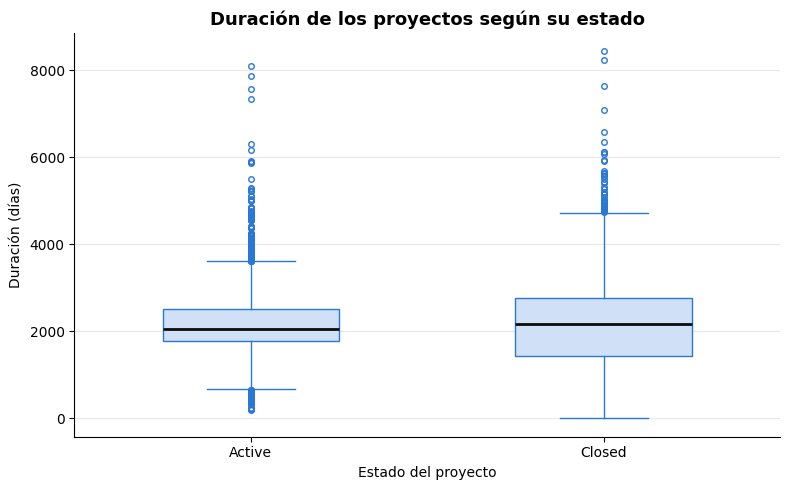

In [22]:
estados = ["Active", "Closed"]

# Una lista con las duraciones de cada estado (sin los nulos)
datos = [df.loc[df["status"] == e, "project_duration_days"].dropna() for e in estados]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    datos, widths=0.5, patch_artist=True,
    boxprops=dict(facecolor="#cfe0f7", edgecolor=COLOR),            # la caja
    medianprops=dict(color="#0b0b0b", linewidth=2),                  # la mediana, bien visible
    whiskerprops=dict(color=COLOR), capprops=dict(color=COLOR),      # las líneas que salen de la caja
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor=COLOR, markersize=4),  # atípicos
)
ax.set_xticks([1, 2])
ax.set_xticklabels(estados)

ax.set_title("Duración de los proyectos según su estado")
ax.set_xlabel("Estado del proyecto")
ax.set_ylabel("Duración (días)")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Lectura de la gráfica

- **Las medianas son parecidas:** unos 2,060 días en `Active` y 2,170 en `Closed` (alrededor de seis años).
- **`Closed` es más disperso:** su caja va de unos 1,440 a 2,760 días y llega casi a cero, mientras que `Active` es más concentrado (de unos 1,770 a 2,510). Entre los `Closed` hay 579 proyectos que duraron menos de un año.
- **Hay proyectos atípicos de hasta unos 8,000 días (22 años)** en ambos estados, y en `Active` también algunos de menos de 700 días, probablemente aprobados hace poco con un cierre planeado corto.
- Recordar que en `Active` la duración es planeada y en `Closed` es real, así que la comparación es orientativa.

### 4.5 Los 10 países con más financiamiento

Se usan **barras horizontales**, que se leen mejor cuando los nombres son largos. El país con más financiamiento queda arriba.

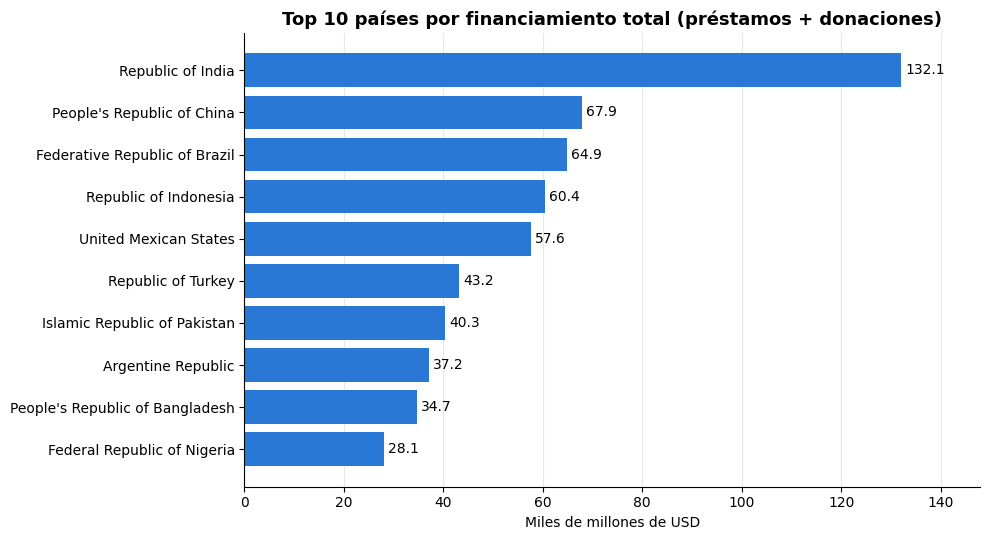

In [25]:
valores = (paises / 1e9)                              # miles de millones de USD

fig, ax = plt.subplots(figsize=(10, 5.5))
barras = ax.barh(valores.index, valores.values, color=COLOR)
ax.bar_label(barras, fmt="{:,.1f}", padding=3)
ax.invert_yaxis()                                     # el mayor queda arriba
ax.set_xlim(0, valores.max() * 1.12)                  # deja espacio para la etiqueta de la barra más larga

ax.set_title("Top 10 países por financiamiento total (préstamos + donaciones)")
ax.set_xlabel("Miles de millones de USD")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Lectura de la gráfica

India (132.1) supera ampliamente a China (67.9), Brasil (64.9), Indonesia (60.4) y México (57.6), que forman un segundo grupo bastante parejo. Después hay un escalón hacia Turquía, Pakistán, Argentina, Bangladesh y Nigeria (entre 43 y 28 mil millones). Estos montos son **nominales**, **acumulados desde 1947** e incluyen proyectos `Dropped` y `Pipeline`, es decir, financiamiento comprometido y no necesariamente ejecutado.

---
## ✅ Conclusiones

El análisis descriptivo de 18,048 proyectos de financiamiento del Banco Mundial deja los siguientes hallazgos principales:

1. **Volumen y dinero no coinciden.** África tiene el mayor número de proyectos (31% del total) pero proyectos pequeños (mediana de 18 millones), mientras que Asia del Sur tiene pocos proyectos y los más grandes (mediana de 50 millones). Latinoamérica y el Caribe es la región con mayor financiamiento total (255 mil millones, 20.9%).
2. **El proyecto "típico" es mucho más pequeño que el promedio.** La mediana es de 25 millones de USD frente a un promedio de 67.6 millones; el sesgo lo provocan pocos proyectos muy grandes. Por eso, para describir el caso típico conviene usar la mediana.
3. **Las donaciones importan.** El 18.9% de los proyectos no tiene préstamo y la gran mayoría de ellos (3,305) se financia con donaciones; sin la medida `total_financing` se habría subestimado el financiamiento.
4. **El financiamiento está concentrado.** Diez países reciben el 46.4% del total, y solo India el 10.8%.
5. **La actividad creció por etapas** hasta el pico de 2010 (649 proyectos aprobados en un año) y luego oscila sin tendencia clara.
6. **Un proyecto dura cerca de seis años** (mediana de 5.9 años en los cerrados), y los activos tienen una duración planeada similar.

### Cierre

El análisis descriptivo confirma la importancia de la calidad de los datos: gracias al ETL previo, las estadísticas y gráficas parten de una base consistente, y gracias a la revisión adicional de la sección 2 se evitaron errores de interpretación (un registro de prueba, una columna de costos poco confiable y donaciones que habrían aparecido como "proyectos sin dinero").